# Feature Report
# This notebook summarizes tuned model outputs and example recommendations.
# Reproduce by running:
#   python feature_engineering.py
#   python tune_and_report.py

In [8]:
# Environment & Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


In [9]:
# Configuration and paths
OUT_DIR = 'eda_outputs'
FEATURE_PATH = os.path.join(OUT_DIR, 'feature_matrix.csv')
IMPORTANCE_PATH = os.path.join(OUT_DIR, 'feature_importances.csv')
TOPN_PATH = os.path.join(OUT_DIR, 'topN_examples.csv')
MODEL_PATH = os.path.join(OUT_DIR, 'tuned_model.pkl')

features = [
    "tfidf_cosine",
    "embedding_cosine",
    "shared_skills_count",
    "fuzzy_skill_score",
    "resume_word_count",
    "job_word_count",
    "resume_num_skills",
    "job_num_skills",
]

In [10]:
# Helper functions

def load_features(path=FEATURE_PATH):
    return pd.read_csv(path)

def show_top_features(path=IMPORTANCE_PATH, top_n=20):
    df = pd.read_csv(path, index_col=0)
    display(df.head(top_n))
    ax = df.head(top_n).plot.barh(figsize=(8,6))
    ax.invert_yaxis()
    plt.title('Top feature importances')
    plt.tight_layout()


In [6]:
# Load datasets and quick preview
feat = load_features()
print('feature matrix shape:', feat.shape)
display(feat.head())


feature matrix shape: (10000, 20)


,resume_index,job_index,resume_id,job_id,tfidf_cosine,resume_len,job_len,resume_num_skills,job_num_skills,shared_skills_count,shared_skills_ratio,resume_word_count,resume_char_count,resume_sentence_count,job_word_count,job_char_count,job_sentence_count,fuzzy_skill_score,embedding_cosine,label
0,0,0,1,0,0.25606,2,2,0,0,0,0.0,2,10,2,2,11,2,0.0,0.425289,0
1,0,1,1,1,0.25606,2,2,0,0,0,0.0,2,10,2,2,11,2,0.0,0.425289,1
2,0,2,1,2,0.25606,2,2,0,0,0,0.0,2,10,2,2,11,2,0.0,0.425289,0
3,0,3,1,3,0.25606,2,2,0,0,0,0.0,2,10,2,2,11,2,0.0,0.425289,1
4,0,4,1,4,0.25606,2,2,0,0,0,0.0,2,10,2,2,11,2,0.0,0.425289,0


,importance
embedding_cosine,0.047667
resume_num_skills,0.038708
tfidf_cosine,0.020197
job_word_count,0.003476
resume_word_count,0.000436
shared_skills_count,0.000000
fuzzy_skill_score,0.000000
job_num_skills,0.000000


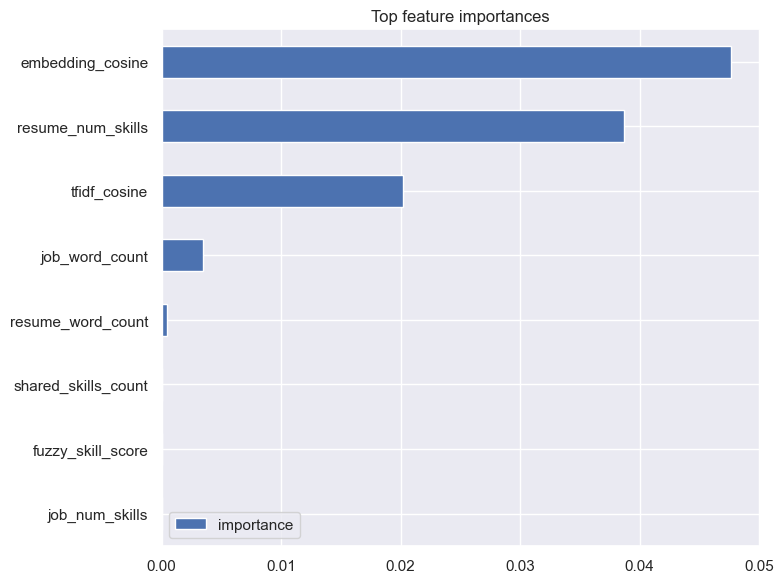

In [5]:
# Show top features
try:
    show_top_features()
except Exception as e:
    print('Could not show feature importances:', e)


In [6]:
# Show top-N recommendations for first example resume
try:
    topn = pd.read_csv(TOPN_PATH)
    display(topn[topn["resume_index"]==topn["resume_index"].min()].head(5))
except Exception as e:
    print('Could not load top-N examples:', e)


,resume_index,job_index,job_id,match_prob
0,0,20,20.0,0.25385
1,0,21,21.0,0.25385
2,0,33,33.0,0.25385
3,0,31,31.0,0.25385
4,0,36,36.0,0.25385


In [ ]:
!pip install xgboost

In [ ]:
# SHAP explanations for feature importance
try:
    import shap
    import joblib
    model = joblib.load(MODEL_PATH)
    X_sample = feat[features].fillna(0.0).astype(float).sample(100, random_state=42)
    # Use TreeExplainer for XGBoost model
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('SHAP failed:', e)

SHAP failed: No module named 'xgboost'
